In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import confusion_matrix , f1_score ,recall_score ,precision_score , accuracy_score

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام اول–بارگذاری مجموعه داده وتحلیل اولیه</p>


In [6]:
cov_type = pd.read_csv('covtype.csv')


In [7]:
print("dataset shape is:" , cov_type.shape)

dataset shape is: (581012, 55)


In [8]:
cov_type

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3


In [9]:
target_counts = cov_type["Cover_Type"].value_counts()
target_counts

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [10]:
target_counts / np.sum(target_counts)

Cover_Type
2    0.487599
1    0.364605
3    0.061537
7    0.035300
6    0.029891
5    0.016339
4    0.004728
Name: count, dtype: float64

In [11]:
cov_type.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


Text(0, 0.5, 'number of sample')

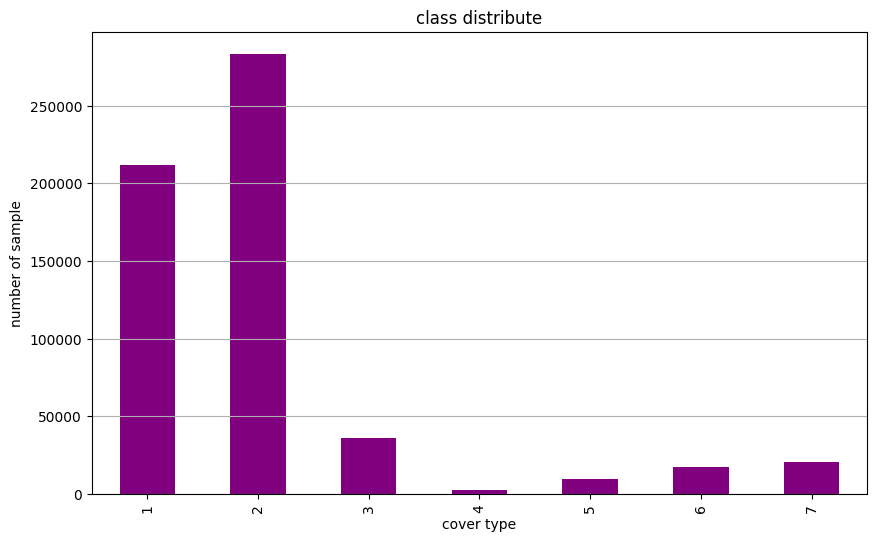

In [12]:
plt.figure(figsize=(10,6))
cov_type["Cover_Type"].value_counts()
target_counts.sort_index().plot(kind="bar" , color="purple")
plt.grid(axis="y")
plt.title("class distribute")
plt.xlabel("cover type")
plt.ylabel("number of sample")

In [13]:
cov_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [14]:
print(cov_type.isnull())
print(cov_type.isnull().sum())
print("totally : ",cov_type.isnull().sum().sum())

        Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           False   False  False                             False   
1           False   False  False                             False   
2           False   False  False                             False   
3           False   False  False                             False   
4           False   False  False                             False   
...           ...     ...    ...                               ...   
581007      False   False  False                             False   
581008      False   False  False                             False   
581009      False   False  False                             False   
581010      False   False  False                             False   
581011      False   False  False                             False   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                False                            False   
1        

In [15]:
cov_type.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [16]:
class_1 = cov_type[cov_type['Cover_Type'] == 1]
class_1_down = resample(class_1,
                        replace=False,
                        n_samples=10000,  
                        random_state=42)

class_2 = cov_type[cov_type['Cover_Type'] == 2]
class_2_down = resample(class_2,
                        replace=False,
                        n_samples=10000,  
                        random_state=42)


class_3 = cov_type[cov_type['Cover_Type'] == 3]
class_3_down = resample(class_3,
                        replace=False,
                        n_samples=10000,  
                        random_state=42)

class_4 = cov_type[cov_type['Cover_Type'] == 4]
class_4_up = resample(class_4,
                        replace=True,
                        n_samples=10000,  
                        random_state=42)

class_5 = cov_type[cov_type['Cover_Type'] == 5]
class_5_up = resample(class_5,
                        replace=True,
                        n_samples=10000,  
                        random_state=42)

class_6 = cov_type[cov_type['Cover_Type'] == 6]
class_6_down = resample(class_6,
                        replace=False,
                        n_samples=10000,  
                        random_state=42)

class_7 = cov_type[cov_type['Cover_Type'] == 7]
class_7_down = resample(class_7,
                        replace=False,
                        n_samples=10000,  
                        random_state=42)



In [17]:
cov_type_train_resampled = pd.concat([class_1_down, class_2_down, class_3_down , class_4_up , class_5_up , class_6_down , class_7_down])  

cov_type_train_resampled["Cover_Type"].value_counts()


Cover_Type
1    10000
2    10000
3    10000
4    10000
5    10000
6    10000
7    10000
Name: count, dtype: int64

In [18]:
# binary_features = [col for col in cov_type_train_resampled.columns 
#                    if cov_type_train_resampled[col].nunique() == 2 and col != "Cover_Type"]

binary_features=[]
for col in cov_type_train_resampled.columns:
    if cov_type_train_resampled[col].nunique() == 2 and col != "Cover_Type":
        binary_features.append(col)

print("number binary features : " , len(binary_features))


number binary features :  44


In [19]:
numerical_features=[]
for col in cov_type_train_resampled.columns:
    if col not in binary_features and col != "Cover_Type":
        numerical_features.append(col)

print("number binary features : " , len(numerical_features))


number binary features :  10


In [20]:
pd.DataFrame(numerical_features).T

,0,1,2,3,4,5,6,7,8,9
0,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points


-----------------------

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام دوم–پیش پردازش</p>


In [21]:
y = cov_type_train_resampled["Cover_Type"]
x = cov_type_train_resampled.drop(columns=["Cover_Type"])

print(x.shape)
print(y.shape)

(70000, 54)
(70000,)


In [22]:
X_train ,x_test ,Y_train , y_test = train_test_split(x , y , random_state=42 ,stratify=y , test_size=0.2)

In [23]:
print(X_train.shape)
print(x_test.shape)
print(Y_train.shape)
print(y_test.shape)

(56000, 54)
(14000, 54)
(56000,)
(14000,)


In [24]:
print(Y_train.value_counts())

print(Y_train.value_counts() / np.sum(Y_train.value_counts()))


Cover_Type
3    8000
2    8000
1    8000
4    8000
7    8000
6    8000
5    8000
Name: count, dtype: int64
Cover_Type
3    0.142857
2    0.142857
1    0.142857
4    0.142857
7    0.142857
6    0.142857
5    0.142857
Name: count, dtype: float64


In [25]:
print(y_test.value_counts())

print(y_test.value_counts() / np.sum(y_test.value_counts()))

Cover_Type
6    2000
2    2000
1    2000
3    2000
7    2000
5    2000
4    2000
Name: count, dtype: int64
Cover_Type
6    0.142857
2    0.142857
1    0.142857
3    0.142857
7    0.142857
5    0.142857
4    0.142857
Name: count, dtype: float64


In [26]:
x_train , x_validation , y_train , y_validation = train_test_split(X_train , Y_train , random_state=43 , test_size=0.25)

In [27]:
print(x_train.shape)
print(x_validation.shape)
print(y_train.shape)
print(y_validation.shape)

(42000, 54)
(14000, 54)
(42000,)
(14000,)


In [28]:
len(cov_type_train_resampled) ==  len(x_train) + len(x_validation) +len(x_test)

True

In [29]:
print("x_train" , len(x_train) / len(cov_type_train_resampled))
print("x_validation" , len(x_validation) / len(cov_type_train_resampled))
print("x_test" , len(x_test) / len(cov_type_train_resampled))

x_train 0.6
x_validation 0.2
x_test 0.2


In [30]:

preprocessor  =  ColumnTransformer(transformers=[
        ('numeric_scaler', StandardScaler(), numerical_features),
        ('passthrough_binary', 'passthrough', binary_features)
])






In [31]:
x_train_std = preprocessor.fit_transform(x_train)


x_validation_std = preprocessor.transform(x_validation)
x_test_std = preprocessor.transform(x_test)

In [32]:
print(x_train[numerical_features].shape)
print(x_train[binary_features].shape)
print(x_train_std.shape)

(42000, 10)
(42000, 44)
(42000, 54)


In [33]:
all_column_names = numerical_features + binary_features

pd.DataFrame(x_train_std  , columns=[all_column_names])

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
0,0.426471,-0.478178,-1.246230,-0.481561,-0.738302,2.119330,0.593127,0.574781,-0.012984,2.586195,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.366628,0.122545,0.405213,-0.943708,-0.672756,-0.105919,0.593127,1.099381,0.030434,1.066990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.164186,-1.033391,-0.538469,-0.943708,-0.853009,0.423256,0.297753,-0.255836,-0.208366,0.479261,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.935849,0.814287,0.995014,-0.767425,-0.426957,-0.207684,-1.737044,1.361682,1.853995,-0.752429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.069524,1.760880,-0.420508,1.943520,-0.771076,1.117516,-0.588368,-0.037253,0.573161,1.681928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,-0.814384,1.360399,0.051332,0.342681,2.620955,-0.390860,-1.343212,0.443631,1.354687,-0.385098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41996,-1.035880,1.451417,-0.656429,-0.943708,-0.754689,-0.370507,-0.752465,0.531064,1.007342,-0.107560,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41997,0.469341,1.496926,-1.010309,0.261686,0.212122,1.116008,-0.457091,0.618498,0.833669,0.610775,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41998,1.262440,-0.569196,-0.066628,0.371267,-0.066451,-0.959987,0.986959,-0.168403,-0.816219,-0.716149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
x_train

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
76705,2925,103,6,127,6,4518,231,232,134,4366,...,0,0,0,0,0,0,0,0,0,0
404266,2592,169,20,30,10,1566,231,244,136,2691,...,0,0,0,0,0,0,0,0,0,0
86306,2677,42,12,30,-1,2268,222,213,125,2043,...,0,0,0,0,0,0,0,0,0,0
300860,2353,245,25,67,25,1431,160,250,220,685,...,0,0,0,0,0,0,0,0,0,0
145265,3195,349,13,636,4,3189,195,218,161,3369,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277197,2404,305,17,300,211,1188,172,229,197,1090,...,0,0,0,0,0,0,0,0,0,0
13192,2311,315,11,30,5,1215,190,231,181,1396,...,0,0,0,0,0,0,0,0,0,0
135264,2943,320,8,283,64,3187,199,233,173,2188,...,0,0,0,0,0,0,0,0,0,0
529932,3276,93,16,306,47,433,243,215,97,725,...,0,0,0,0,0,0,0,0,0,0


-------------------------------

In [35]:
print(x_train_std.shape)
print(x_validation_std.shape)
print(x_test_std.shape)

(42000, 54)
(14000, 54)
(14000, 54)


In [36]:
y_train.shape

(42000,)

In [37]:
# x_train_sample ,_, y_train_sample , _ = train_test_split(x_train_std, y_train , random_state=42 , stratify= y_train , train_size=0.15)

In [38]:
train_acc = []
val_acc = []


n_k = np.array([1, 3, 5, 10, 20, 50])

for k in (n_k):
    k_NN = KNeighborsClassifier(n_neighbors=k)
    k_NN.fit(x_train_std, y_train)

    y_train_pred = k_NN.predict(x_train_std)
    y_val_pred = k_NN.predict(x_validation_std)

    train_acc.append(accuracy_score(y_train_pred , y_train))
    val_acc.append(accuracy_score(y_val_pred , y_validation))






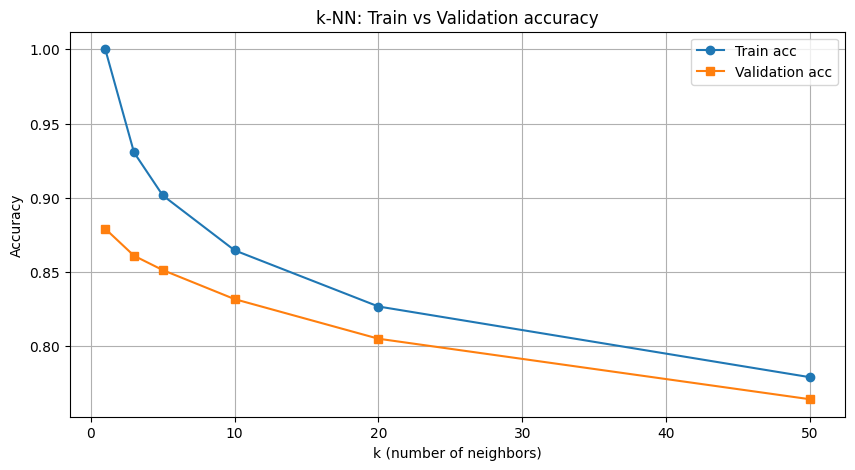

In [39]:
plt.figure(figsize=(10,5))

plt.plot(n_k , train_acc , marker='o', label='Train acc')
plt.plot(n_k , val_acc ,  marker='s', label='Validation acc')
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("k-NN: Train vs Validation accuracy")
plt.legend()
plt.grid(True)

In [40]:
bestK = 5
knn_best = KNeighborsClassifier(n_neighbors=bestK)

knn_best.fit(x_train_std , y_train)

y_val_pred_best = knn_best.predict(x_validation_std)
y_train_pred_best = knn_best.predict(x_train_std)

cm = confusion_matrix(y_validation, y_val_pred)



In [41]:
y_val_pred_best.shape

(14000,)

In [42]:
y_train_pred_best.shape

(42000,)

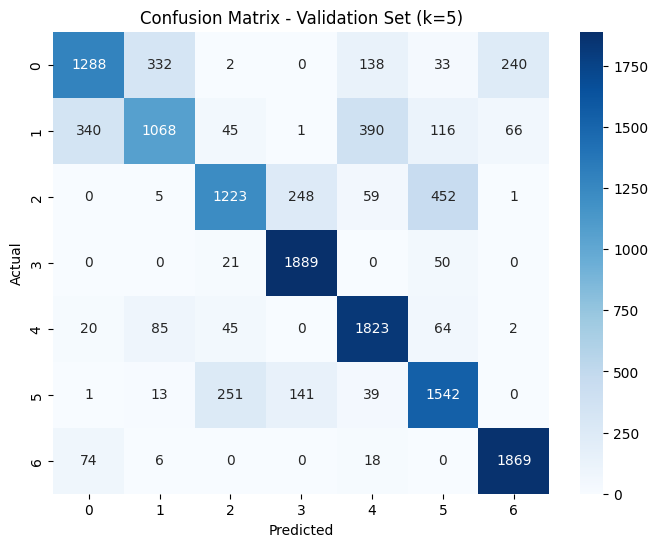

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Validation Set (k={bestK})')
plt.show()

In [44]:
print("\nTrain accuracy (k-NN):", accuracy_score(y_train, y_train_pred_best))

print("\nTrain Precision (macro):", precision_score(y_train, y_train_pred_best, average='macro', zero_division=0))
print("Train Recall (macro):", recall_score(y_train, y_train_pred_best, average='macro', zero_division=0))
print("Train F1-score (macro):", f1_score(y_train, y_train_pred_best, average='macro', zero_division=0))

print("\nTrain Precision (weighted):", precision_score(y_train, y_train_pred_best, average='weighted', zero_division=0))
print("Train Recall (weighted):", recall_score(y_train, y_train_pred_best, average='weighted', zero_division=0))
print("Train F1-score (weighted):", f1_score(y_train, y_train_pred_best, average='weighted', zero_division=0))


Train accuracy (k-NN): 0.9015952380952381

Train Precision (macro): 0.9006129370644288
Train Recall (macro): 0.9013978870654817
Train F1-score (macro): 0.8997216787125334

Train Precision (weighted): 0.9007121301353191
Train Recall (weighted): 0.9015952380952381
Train F1-score (weighted): 0.8998724647196736


In [45]:
y_test_pred  = knn_best.predict(x_test_std)


acc_test = accuracy_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred, average='macro')
rec_test = recall_score(y_test, y_test_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')

In [46]:
print("\nTest accuracy (k-NN):", accuracy_score(y_train, y_train_pred_best))

print("\nTest Precision (macro):", precision_score(y_train, y_train_pred_best, average='macro', zero_division=0))
print("Test Recall (macro):", recall_score(y_train, y_train_pred_best, average='macro', zero_division=0))
print("Test F1-score (macro):", f1_score(y_train, y_train_pred_best, average='macro', zero_division=0))



Test accuracy (k-NN): 0.9015952380952381

Test Precision (macro): 0.9006129370644288
Test Recall (macro): 0.9013978870654817
Test F1-score (macro): 0.8997216787125334


------------------------

In [47]:
y_test_pred = knn_best.predict(x_test_std)

print("Classification Report on Test Data:\n")
print(classification_report(y_test, y_test_pred))

Classification Report on Test Data:

              precision    recall  f1-score   support

           1       0.80      0.76      0.78      2000
           2       0.79      0.67      0.73      2000
           3       0.85      0.77      0.81      2000
           4       0.90      0.98      0.94      2000
           5       0.86      0.96      0.91      2000
           6       0.81      0.85      0.83      2000
           7       0.93      0.98      0.96      2000

    accuracy                           0.85     14000
   macro avg       0.85      0.85      0.85     14000
weighted avg       0.85      0.85      0.85     14000



-------------------

In [48]:
train_acc_tree = []
val_acc_tree = []


max_depths = np.array([2, 4, 8, 12, 20])

for max_depth in (max_depths):

    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(x_train_std , y_train)

    y_train_pred = clf.predict(x_train_std)
    y_val_pred = clf.predict(x_validation_std)

    train_acc_tree.append(accuracy_score(y_train_pred , y_train))
    val_acc_tree.append(accuracy_score(y_val_pred , y_validation))

Text(0.5, 1.0, 'Decision Tree: Train vs Validation accuracy')

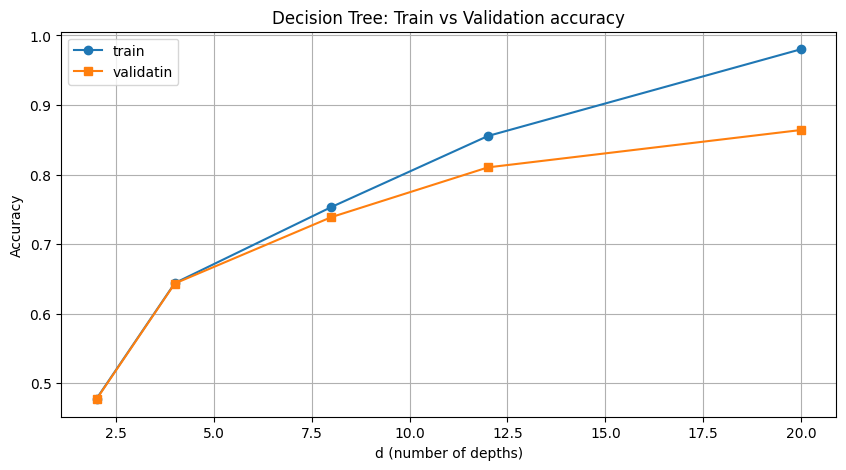

In [49]:
plt.figure(figsize=(10,5))

plt.plot(max_depths , train_acc_tree, marker="o" , label="train")
plt.plot(max_depths , val_acc_tree, marker="s" , label="validatin")
plt.legend()
plt.grid()
plt.xlabel("d (number of depths)")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Validation accuracy")

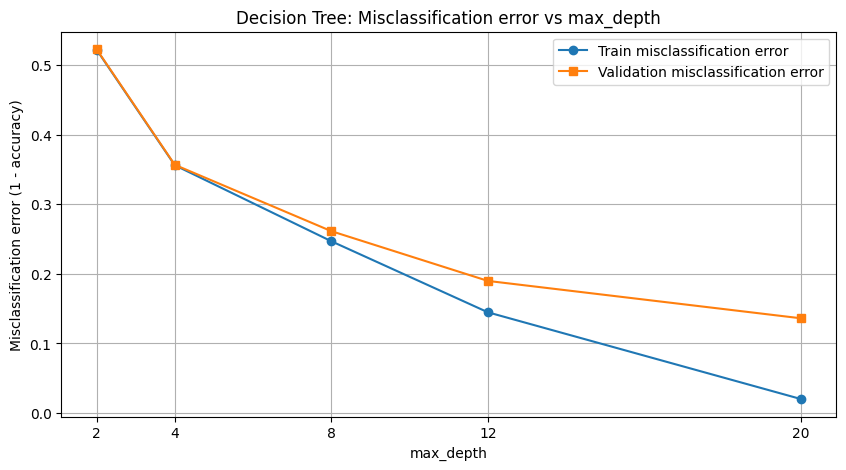

In [50]:
mis_train = [1 - a for a in train_acc_tree]
mis_val   = [1 - a for a in val_acc_tree]

plt.figure(figsize=(10,5))
plt.plot(max_depths, mis_train, marker='o', label='Train misclassification error')
plt.plot(max_depths, mis_val, marker='s', label='Validation misclassification error')
plt.xticks(max_depths)
plt.xlabel("max_depth")
plt.ylabel("Misclassification error (1 - accuracy)")
plt.title("Decision Tree: Misclassification error vs max_depth")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_depth = 8

x_train_tree = np.vstack((x_train_std, x_validation_std))
y_train_tree = np.hstack((y_train, y_validation))


clf_best = DecisionTreeClassifier(max_depth=12)
clf_best.fit(x_train_tree , y_train_tree)

y_train_pred = clf_best.predict(x_train)
y_test_pred = clf_best.predict(x_test_std)
print(classification_report(y_test, y_test_pred))




              precision    recall  f1-score   support

           1       0.76      0.72      0.74      2000
           2       0.71      0.65      0.68      2000
           3       0.77      0.78      0.77      2000
           4       0.95      0.97      0.96      2000
           5       0.81      0.91      0.86      2000
           6       0.79      0.76      0.78      2000
           7       0.94      0.95      0.94      2000

    accuracy                           0.82     14000
   macro avg       0.82      0.82      0.82     14000
weighted avg       0.82      0.82      0.82     14000



In [53]:
acc_train = accuracy_score(y_train, y_train_pred)
prec_train = precision_score(y_train, y_train_pred, average='macro')
rec_train = recall_score(y_train, y_train_pred, average='macro')
f1_train = f1_score(y_train, y_train_pred, average='macro')

acc_test = accuracy_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred, average='macro')
rec_test = recall_score(y_test, y_test_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')

In [57]:
print("train DecisionTree")
print("accuracy", acc_train)
print("Precision (macro):", prec_train)
print("Recall (macro):",rec_train)
print("F1-score (macro):", f1_train)
print("--------------------------------")
print("test DecisionTree")
print("accuracy", acc_test)
print("Precision (macro):", prec_test)
print("Recall (macro):",rec_test)
print("F1-score (macro):", f1_test)

train DecisionTree
accuracy 0.9801428571428571
Precision (macro): 0.9802157563304789
Recall (macro): 0.9800848338105641
F1-score (macro): 0.9800408541473689
--------------------------------
test DecisionTree
accuracy 0.8197857142857143
Precision (macro): 0.8175424415387206
Recall (macro): 0.8197857142857142
F1-score (macro): 0.8179177758909609


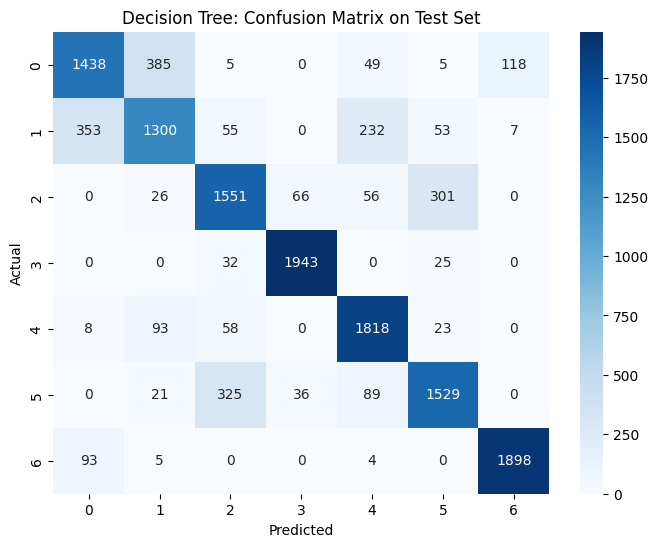

In [55]:
cm_tree = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree: Confusion Matrix on Test Set')
plt.show()

------------

In [58]:
estimator = LinearDiscriminantAnalysis()

estimator.fit(x_train_std , y_train)

y_prd_train = estimator.predict(x_train_std)
y_prd_vali = estimator.predict(x_validation_std)
y_prd_test = estimator.predict(x_test_std)


In [59]:
acc_train = accuracy_score(y_train, y_prd_train)
prec_train = precision_score(y_train, y_prd_train, average='macro')
rec_train = recall_score(y_train, y_prd_train, average='macro')
f1_train = f1_score(y_train, y_prd_train, average='macro')

acc_test = accuracy_score(y_test, y_prd_test)
prec_test = precision_score(y_test, y_prd_test, average='macro')
rec_test = recall_score(y_test, y_prd_test, average='macro')
f1_test = f1_score(y_test, y_prd_test, average='macro')

In [60]:
print("train LDA")
print("accuracy", acc_train)
print("Precision (macro):", prec_train)
print("Recall (macro):",rec_train)
print("F1-score (macro):", f1_train)
print("--------------------------------")
print("test LDA")
print("accuracy", acc_test)
print("Precision (macro):", prec_test)
print("Recall (macro):",rec_test)
print("F1-score (macro):", f1_test)

train LDA
accuracy 0.6491428571428571
Precision (macro): 0.6568605621722649
Recall (macro): 0.6488919379052408
F1-score (macro): 0.6518930867968529
--------------------------------
test LDA
accuracy 0.6405714285714286
Precision (macro): 0.6497210456986272
Recall (macro): 0.6405714285714286
F1-score (macro): 0.6439887221857232


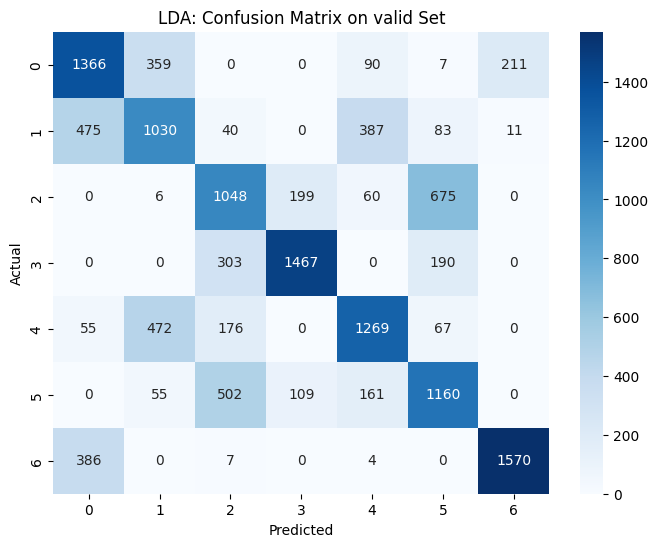

In [61]:
cm_estimator = confusion_matrix(y_validation, y_prd_vali)
plt.figure(figsize=(8,6))
sns.heatmap(cm_estimator, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LDA: Confusion Matrix on valid Set')
plt.show()

In [63]:

print("\nTrain Precision (weighted):", precision_score(y_train, y_prd_train, average='weighted', zero_division=0))
print("Train Recall (weighted):", recall_score(y_train, y_prd_train, average='weighted', zero_division=0))
print("Train F1-score (weighted):", f1_score(y_train, y_prd_train, average='weighted', zero_division=0))


Train Precision (weighted): 0.6572456367062866
Train Recall (weighted): 0.6491428571428571
Train F1-score (weighted): 0.6522085327800432


--------------------